In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
import seaborn as snb
from typing import NamedTuple
from typing import Tuple

from scipy.stats import binom as binom_dist
from scipy.stats import beta as beta_dist
from scipy.special import gammaln
from scipy.special import beta as beta_fun

snb.set_style('darkgrid')
snb.set(font_scale=1.5)
plt.rcParams['lines.linewidth'] = 3


# Assignment 1 - 02477 Bayesian Machine Learning

Date: 05/03/2026

Bella Strandfort (s214215) & Sofie Ullum Jensen (s224185)

## Part 1 - The beta-binomial model

We have the following know parameters:
$$N = 115 \qquad y = 4 \qquad \theta\in [0,1] \qquad  N^* = 20  \qquad   y^* = ?$$
And the models:
\begin{align*}
\theta & \sim \text{Beta}(a_0, b_0) \qquad \text{where} \quad a_0=b_0=1\\
y|\theta & \sim \text{Binomial}(N,\theta)
\end{align*}

In [ ]:
# Defining parameters
N = 115
y = 4
N_s = 20
a0 = 1
b0 = 1

### Task 1.1 Prior mean and 95%-credibility interval
The mean of a beta distribution is given by
$$\mathbb{E}\left[\theta\right]  = \frac{a_0}{a_0+b_0} = \frac{1}{2}$$

Since a beta distribution with both parameters equal to 1, corresponds to a uniform distribution over the interval [0,1], a 95% credibility interval is given by

$$ [\frac{1}{2}-\frac{0.95}{2},\frac{1}{2}+\frac{0.95}{2}] =  [0.025, 0.975]$$

### Task 1.2 Posterior mean and 95%-credibility interval

We know that the posterior of theta is another beta distribution given by:
$$ p(\theta|y) = \text{Beta}(\theta|a_0 + y, b_0 + N-y) $$

Therfore the posterior mean is:
$$E_{p(\theta|y)} = \frac{a_0 + y}{a_0 +y + b_0 + N -y} =  \frac{a_0 + y}{a_0 + b_0 + N} = \frac{1 + 4}{1 + 1 + 115 } = \frac{5}{117}$$

For the credibility interval, we will use the Beta distribtution defined in exercise 1:

In [ ]:
class BetaDistribution(NamedTuple):
    # From exercise 1
    a:  int
    b:  int

    def pdf(self, theta):
        """ returns Beta(theta|a,b) """
        return beta_dist.pdf(theta, a=self.a, b=self.b)
    
    @property
    def mean(self):
        """ returns mean of Beta(a,b)-distribution """
        return self.a/(self.a + self.b)
    
    @property
    def variance(self):
        """ returns variance of Beta(a,b)-distribution """
        return self.a*self.b/(self.a + self.b)**2/(self.a + self.b + 1)
    
    @property
    def mode(self):
        """ returns mode of Beta(a,b)-distribution (assuming it exists) """
        return (self.a - 1)/(self.a+self.b-2)
    
    def get_interval(self, interval_size):
        """ returns a tuple representing a interval_size% credibility interval of
          Beta(a,b) using scipy.stats.beta.interval  """
        return beta_dist.interval(interval_size/100, a=self.a, b=self.b)
    
    def sample(self, num_samples):
        return beta_dist.rvs(a=self.a, b=self.b, size=num_samples)

In [5]:
prior = BetaDistribution(a=a0, b=b0)
posterior = BetaDistribution(prior.a + y, prior.b + N - y)

l,u = posterior.get_interval(95)
print(f"[{l:.3f},{u:.3f}]")

[0.014,0.086]


From the Beta distribtion class, we get that the $95%$-credibility interval is $[0.014,0.086]$

### Task 1.3 Posterior predictive distribution

The posterior predictive distribution is given by:
$$p(y^* = k |y) = \binom{N^*}{k} \cdot  \frac{B(\alpha+k,\beta+N^*-k)}{B(\alpha,\beta)}$$
In the plot below, we see the posterior predictive distribution for $y*$ given $y=4$

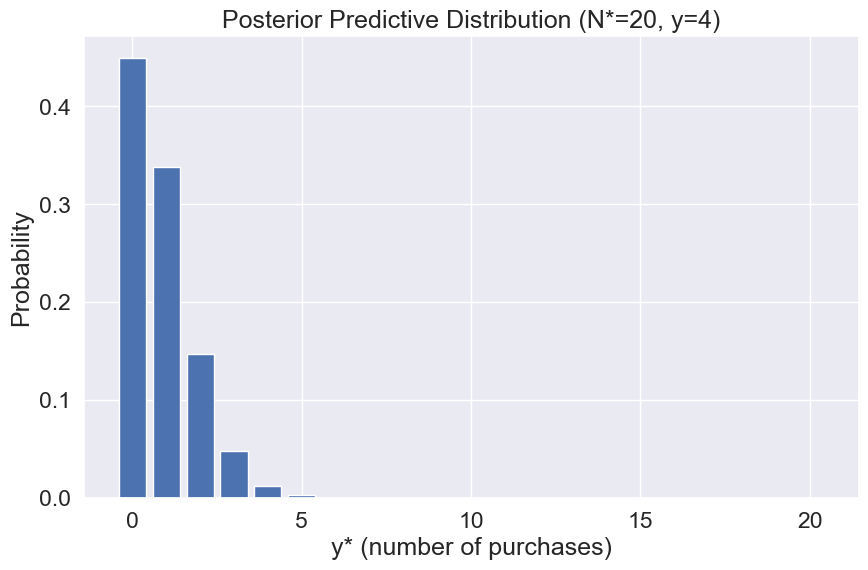

In [6]:
# Sample from posterior
num_samples = 10000
theta_samples = posterior.sample(num_samples)

y_s = jnp.arange(0, N_s + 1)

ppd = jnp.array([
    jnp.mean(binom_dist.pmf(k, N_s, theta_samples))
    for k in y_s
])


ppd = ppd / jnp.sum(ppd)

# Plot it
plt.figure(figsize=(10, 6))
plt.bar(y_s, ppd)
plt.xlabel('y* (number of purchases)')
plt.ylabel('Probability')
plt.title(f'Posterior Predictive Distribution (N*={N_s}, y={y})')
plt.show()

### Task 1.4 Posterior predictive probability for $N^*=20$

To find the probability, that at least one of the next $N^*=20$ customers will make a purchase, we must sum the probabilities, for $y^* \geq 1$

In [13]:
prob_at_least_one = jnp.sum(ppd[1:])
print(f"p(y* >= 1|y) = {prob_at_least_one*100:.2f}")

p(y* >= 1|y) = 55.07


This gives that there is a $55.07\%$ chance that at least one of the next 20 customers will make a purchase

### Task 1.5 Mean and variance of the posterior predictive distribution

Since the posterior predictive distribution follows a Beta distribution, we get that the mean is

$$
\mathbb{E}[y^*|y] = N^* \mathbb{E}[\theta|y] = 20 \cdot \frac{5}{117} = \frac{100}{117}
$$

and the variance is 

$$
\text{Var}[y^*|y]=N^* \frac{\alpha\beta}{(\alpha+\beta)^2} \frac{\alpha+\beta+N^*}{\alpha+\beta+1} = 20 \frac{560}{(5+112)^2} \frac{5+112+20}{5+112+1}= \frac{1534400}{1615302}\approx 0.95
$$

## Part 2: Linear Gaussian System

### Task 2.1 Determine $p(y)$

We find the marginal distribution $p(y)$ by integrating over $z_1$ and $z_2$ in the joint distribution:
$$p(y) = \int \int p(y, z_1, z_2) \text{d}z_1\text{d}z_2 = \int \int p(y|z_2)p(z_2|z_1)p(z_1) \text{d}z_1\text{d}z_2 $$

We can find this integral by splitting the integration in two parts. First, we integrate over $z_1$, which will give us $z_2$ since $z_2$ does not depend on $y$:
$$p(z_2) = \int p(z_2|z_1)p(z_1) \text{d}z_1 = \int \mathcal{N}(z_1, vI)\mathcal{N}(0, vI) \text{d}z_1$$

Using (3.38) from Murphy1 with proper identification of the means and variances, we get:
$$p(z_2) = \mathcal{N}(z_2 | 0, 2vI)$$

Then we can find the marginal distribution of $y$ as:
$$p(y) = \int p(y|z_2)p(z_2) \text{d}z_2 = \int \mathcal{N}(a^Tz_2, \sigma^2) \mathcal{N}(z_2 | 0, 2vI) \text{d}z_2$$

Again using equation (3.38) we finally get:
$$p(y) = \mathcal{N}(0, \sigma^2 +a^T2vIa) = \mathcal{N}(0, \sigma^2 +2v a^TIa) = \mathcal{N}(0, \sigma^2 +2v ||a||^2) $$


### Task 2.2 Determine $p(y,z_2|z_1)$

We start by using the conditional probability and inserting the expression for the joint probability:
$$p(y, z_2|z_1) = \frac{p(y,z_2, z_1)}{p(z_1)} = \frac{p(y|z_2)p(z_2|z_1)p(z_1)}{p(z_1)} = p(y|z_2)p(z_2|z_1)$$

Therefore $p(y, z_2|z_1)$ can be written as:
$$p(y, z_2|z_1) = \mathcal{N}(a^Tz_2, \sigma^2)\mathcal{N}(z_1, vI)$$
$$

### Task 2.3 Determine $p(y|z_1)$

Again we start by using the conditional probability:
$$p(y|z_1) = \frac{p(y, z_1)}{p(z_1)}$$

The joint distribution p(y, z_1) can be found by taking integrating the joint distribution over all three variables with regards to $z_2$:
$$p(y|z_1) = \frac{\int p(y, z_2, z_1) \text{d}z_2}{p(z_1)}$$

By inserting and simplifying we arrive at:
$$p(y|z_1) = \frac{\int p(y|z_2)p(z_2|z_1)p(z_1) \text{d}z_2}{p(z_1)} = \frac{p(z_1) \int p(y|z_2)p(z_2|z_1) \text{d}z_2}{p(z_1)} = \int p(y|z_2)p(z_2|z_1) \text{d}z_2$$

If we insert the expressions for the normal distributions and again use (3.38) from Murphy1 we get:
$$p(y|z_1) =\int p(y|z_2)p(z_2|z_1) \text{d}z_2 = \int \mathcal{N}(a^Tz_2,\sigma^2)\mathcal{N}(z_1, vI) \text{d}z_2 = \mathcal{N}(a^Tz_1, \sigma^2 + v||a||^2)$$

### Task 2.4 Determine $p(z_1|y)$

First, we use Bayes rule:
$$p(z_1|y) = \frac{p(y|z_1)p(z_1)}{p(y)}$$
Since we derived both $p(y|z_1)$ and $p(y)$ above, we can write this as:
$$p(z_1|y) = \frac{\mathcal{N}(a^Tz_1, \sigma^2 + v||a||^2)\mathcal{N}(0,vI)}{\mathcal{N}(0,\sigma^2 + 2v||a||^2)}$$

## Part 3: Conjugate model for count data

In this exercise we have the following model

\begin{align*}
y_i|\lambda &\sim \text{Poisson}(\lambda)\\
\lambda &\sim \text{Gamma}(a_0,b_0)
\end{align*}

where the probability mass function for the Poisson distribution is
$$
p(y_i|\lambda) = \frac{\lambda^{y_i}e^{-\lambda}}{y_i!}
$$

and the probability density function for the Gamma distribution is
$$
p(\lambda|a_0,b_0)=\frac{b_0^{a_0}}{\Gamma(a_0)}\lambda^{a_0-1}e^{-b_0\lambda}
$$

### Task 3.1 Determine the joint distribution

The joint distribution $p(y,\lambda)$ can be written using conditional probability as:
$$p(\mathbf{y},\lambda) = p(\mathbf{y}|\lambda)p(\lambda)$$

Since ${y_i}$ are assumed to be conditionally independent given $\lambda$, the likelihood for $\mathbf{y}$ can be written as a product:
$$
p(\mathbf{y}|\lambda) = \prod_{i=1}^{N} \frac{\lambda^{y_i}e^{-\lambda}}{y_i!} = \frac{\lambda^{\sum_{i=1}^{N} y_i}e^{-N\lambda}}{\prod_{i=1}^{N} y_i!}
$$

Using this likelihood and the prior for $\lambda$, the joint distribution for all $n$ observations becomes

$$\begin{align*}
p(\mathbf{y},\lambda)=p(\mathbf{y}|\lambda)p(\lambda|a_0,b_0)&=\frac{\lambda^{\sum y_i}e^{-N\lambda}}{\prod y_i!}\frac{b_0^{a_0}}{\Gamma(a_0)}\lambda^{a_0-1}e^{-b_0\lambda}\\
&=\frac{b_0^{a_0}}{\prod y_i!\Gamma(a_0)}\lambda^{\sum y_i+a_0-1}e^{-(N+b_0)\lambda}
\end{align*}$$

### Task 3.2 Functional form of a Gamma distribution

In order to show that the functional form of a Gamma distribution is given by $\log p(\lambda|a,b)=(a-1)\lambda - b\lambda + \text{constant}$, we must apply $log$ to the pdf of the Gamma distribution

$$
\log(p(\lambda|a,b))=\log \frac{b^a}{ \Gamma(a)}\lambda^{a-1}e^{-b\lambda}
$$

Using the rules for logarithms we get
$$
= \log b^a - \log \Gamma(a) + (a-1)\log \lambda-b\lambda 
$$

Since $\log b^a$ and $\Gamma(a)$ are independent of $\lambda$, they are constant. And we therefore get

$$
=(a-1)\log(\lambda)-b\lambda+\text{constant}
$$

as the functional form of a Gamma distribution.

### Task 3.3 Posterior distribution $p(\lambda|y)$

In order to find the posterior distribution $p(\lambda|\mathbf{y})$, we must use Bayes rule, which states that

$$\begin{align*}
p(\lambda|\mathbf{y})=\frac{p(\mathbf{y}|\lambda)p(\lambda)}{p(\mathbf{y})}=\frac{p(\mathbf{y}|\lambda)p(\lambda|a_0,b_0)}{p(\mathbf{y})}=\frac{p(\mathbf{y}|\lambda)p(\lambda|a_0,b_0)}{\int p(\mathbf{y}|\lambda')p(\lambda'|a_0,b_0)d\lambda'}
\end{align*}$$

Here we can see that, we have the joint distribution we found in 3.1 in both the numerator and denominator, which gives

$$\begin{align*}
p(\lambda|\mathbf{y})=\frac{\frac{b_0^{a_0}}{\prod y_i!\Gamma(a_0)}\lambda^{\sum y_i+a_0-1}e^{-(N+b_0)\lambda}}{\int \frac{b_0^{a_0}}{\prod y_i!\Gamma(a_0)}\lambda'^{\sum y_i+a_0-1}e^{-(N+b_0)\lambda'} d\lambda'}
\end{align*}$$

Deriving the integral in the denominator we get
$$\begin{align*}
\int \frac{b_0^{a_0}}{\prod y_i!\Gamma(a_0)}\lambda'^{\sum y_i+a_0-1}e^{-(N+b_0)\lambda'} d\lambda'= \frac{b_0^{a_0}\Gamma(\sum y_i+a_0)}{\prod y_i!\Gamma(a_0)(N+b_0)^{\sum y_i+a_0}}
\end{align*}$$

This is constant with regards to $\lambda$, which means that the posterior is proportional to the joint distribution
$$\begin{align*}
p(\lambda|\mathbf{y})\propto\lambda^{\sum y_i+a_0-1}e^{-(N+b_0)\lambda}
\end{align*}$$

In order to show that it is a Gamma distribution, we can now take log of the posterior

$$\begin{align*}
\log p(\lambda|\mathbf{y})&\propto
\log\lambda^{\sum y_i+a_0-1}e^{-(N+b_0)\lambda}\\
&= (\sum y_i+a_0-1)\log \lambda-(N+b_0)\lambda
\end{align*}$$

This is the same as the functional form of a Gamma distribution with parameters $a=a_0+\sum_{i=1}^{N} y_i$ and $b=b_0+N$, so the posterior must be the following Gamma function: 

$$
p(\lambda|\mathbf{y}) = \text{Gamma}\left(\lambda\,\bigg|\,a_0+\sum_{i=1}^{N} y_i,\, b_0+N\right)
$$

### Task 3.4 Posterior distribution for $\lambda$

If we observe $y_1=7$,$ y_2=4$,$y_3=8$,$y_4=11$, and $y_5=12$, such that $N=5$, and assuming that $a_0=1$ and $b_0=\frac{1}{10}$, we can compute the posterior distribution

First, we plug-in the numbers in our above expression for the posterior:
$$
p(\lambda|\mathbf{y}) = \text{Gamma}\left(\lambda\,\bigg|\,1+(7+4+8+11+12),\, \frac{1}{10}+5\right) = \text{Gamma}\left(\lambda\,\bigg|\,43,\, \frac{51}{10}\right)
$$

Then, following the hint, the mean of the posterior is:
$$\mathbb{E}[\lambda]=\frac{43}{\frac{51}{10}} = \frac{430}{51} \approx 8.43$$


### Task 3.5 Plot $p(\lambda)$ and $p(\lambda|y)$ for $\lambda\in[0,30]$

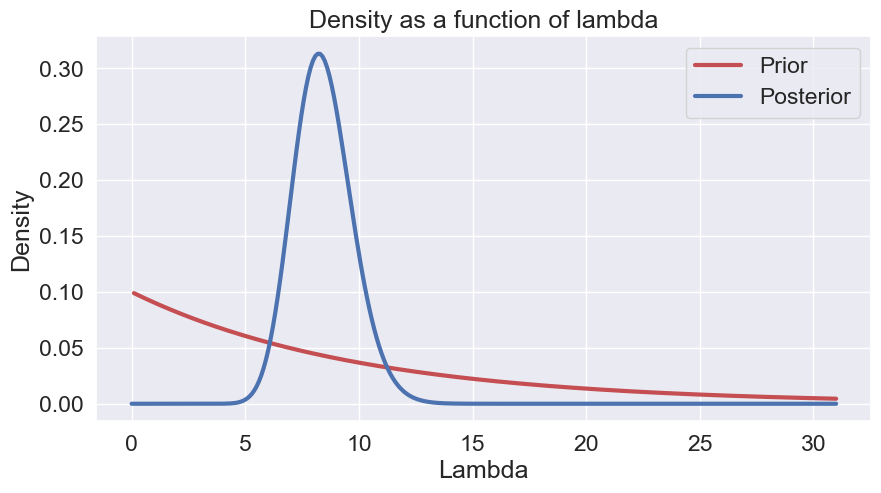

In [27]:
lambdas = jnp.linspace(0,30+1,300)
y_obs = [7,4,8,11,12]
N=len(y_obs)

# Prior
a0 = 1
b0 = 1/10

# Posterior
a1 = a0 + sum(y_obs)
b1 = b0 + N

def log_gamma_pdf(l,a,b):
    return (a-1)*jnp.log(l) - b*l + jnp.log(b**a) - gammaln(a)

# Compute prior and posterior
log_prior = log_gamma_pdf(lambdas, a0, b0)
prior = jnp.exp(log_prior)
log_posterior = log_gamma_pdf(lambdas, a1, b1)
posterior = jnp.exp(log_posterior)

# Plot distribution
plt.figure(figsize=(10,5))
plt.plot(lambdas, prior, color="r", label="Prior")
plt.plot(lambdas, posterior, color="b", label="Posterior")
plt.xlabel("Lambda")
plt.ylabel("Density")
plt.legend()
plt.title("Density as a function of lambda")
plt.show()

